In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = r"D:\Fruit Disease detection\Mango Fruit Dataset"

print("Dataset path:")
print(dataset_path)

print("\nItems inside dataset:")
print(os.listdir(dataset_path))

Dataset path:
D:\Fruit Disease detection\Mango Fruit Dataset

Items inside dataset:
['Alternaria', 'Anthracnose', 'Black Mould Rot', 'Healthy', 'Stem end Rot']


In [2]:
print("FOLDERS")
print("=" * 50)

for item in sorted(os.listdir(dataset_path)):

    item_path = os.path.join(dataset_path, item)

    if os.path.isdir(item_path):

        print("\nFolder:", item)

        contents = os.listdir(item_path)

        print("Number of items:", len(contents))

        print("First few items:")
        print(contents[:10])

FOLDERS

Folder: Alternaria
Number of items: 1000
First few items:
['alternaria_001.jpg', 'alternaria_002.jpg', 'alternaria_003.jpg', 'alternaria_004.jpg', 'alternaria_005.jpg', 'alternaria_006.jpg', 'alternaria_007.jpg', 'alternaria_008.jpg', 'alternaria_009.jpg', 'alternaria_010.jpg']

Folder: Anthracnose
Number of items: 1000
First few items:
['anthracnose_001.jpg', 'anthracnose_002.jpg', 'anthracnose_003.jpg', 'anthracnose_004.jpg', 'anthracnose_005.jpg', 'anthracnose_006.jpg', 'anthracnose_007.jpg', 'anthracnose_008.jpg', 'anthracnose_009.jpg', 'anthracnose_010.jpg']

Folder: Black Mould Rot
Number of items: 1000
First few items:
['aspergillus_001.jpg', 'aspergillus_002.jpg', 'aspergillus_003.jpg', 'aspergillus_004.jpg', 'aspergillus_005.jpg', 'aspergillus_006.jpg', 'aspergillus_007.jpg', 'aspergillus_008.jpg', 'aspergillus_009.jpg', 'aspergillus_010.jpg']

Folder: Healthy
Number of items: 1000
First few items:
['aug_0_healthy_001.jpg', 'aug_100_healthy_101.jpg', 'aug_101_healthy_

In [3]:
class_folders = []

for item in sorted(os.listdir(dataset_path)):

    item_path = os.path.join(dataset_path, item)

    if os.path.isdir(item_path):

        # Check whether this folder contains image files
        image_files = [
            f for f in os.listdir(item_path)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".webp")
            )
        ]

        if len(image_files) > 0:
            class_folders.append(item)

print("Detected class folders:")
print(class_folders)

print("\nNumber of classes:", len(class_folders))

Detected class folders:
['Alternaria', 'Anthracnose', 'Black Mould Rot', 'Healthy', 'Stem end Rot']

Number of classes: 5


In [4]:
class_counts = {}

for class_name in class_folders:

    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ]

    class_counts[class_name] = len(image_files)


print("CLASS DISTRIBUTION")
print("=" * 50)

for class_name, count in class_counts.items():

    print(f"{class_name:30s} : {count}")

print("=" * 50)

total_images = sum(class_counts.values())

print("Total images:", total_images)
print("Total classes:", len(class_counts))

CLASS DISTRIBUTION
Alternaria                     : 1000
Anthracnose                    : 1000
Black Mould Rot                : 1000
Healthy                        : 1000
Stem end Rot                   : 1000
Total images: 5000
Total classes: 5


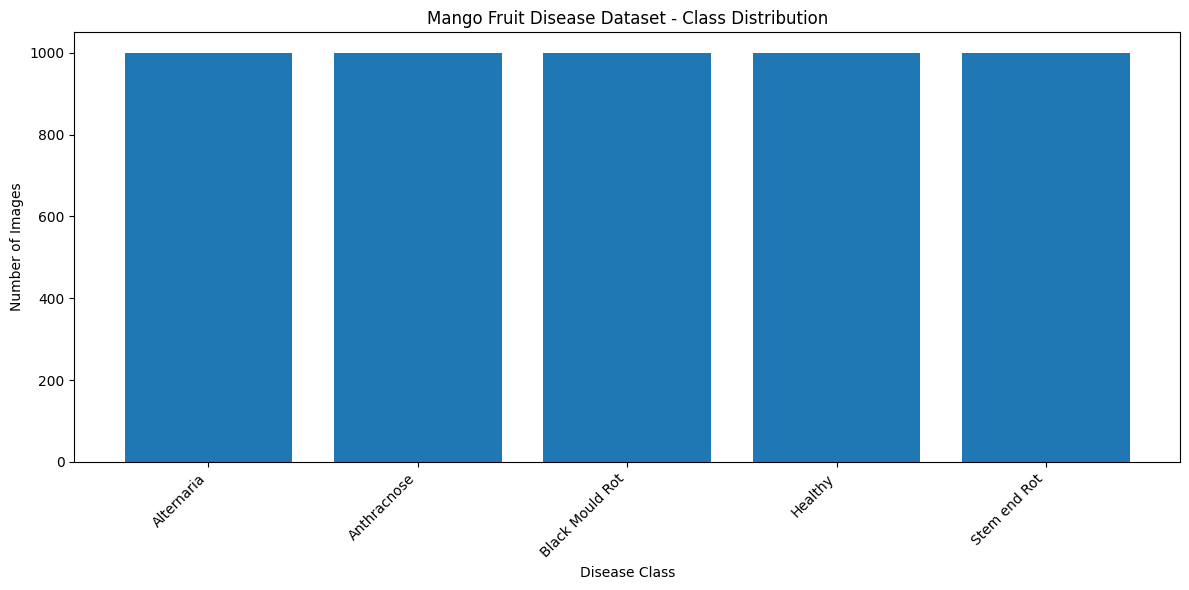

In [5]:
plt.figure(figsize=(12, 6))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Mango Fruit Disease Dataset - Class Distribution")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [6]:
df_distribution = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Number of Images"]
)

print(df_distribution)

             Class  Number of Images
0       Alternaria              1000
1      Anthracnose              1000
2  Black Mould Rot              1000
3          Healthy              1000
4     Stem end Rot              1000


In [7]:
df_distribution["Percentage"] = (
    df_distribution["Number of Images"]
    / total_images
    * 100
)

print(df_distribution)

             Class  Number of Images  Percentage
0       Alternaria              1000        20.0
1      Anthracnose              1000        20.0
2  Black Mould Rot              1000        20.0
3          Healthy              1000        20.0
4     Stem end Rot              1000        20.0


In [8]:
max_class = max(class_counts, key=class_counts.get)
min_class = min(class_counts, key=class_counts.get)

print("Largest class:")
print(max_class, ":", class_counts[max_class])

print("\nSmallest class:")
print(min_class, ":", class_counts[min_class])

print("\nImbalance ratio:")

ratio = class_counts[max_class] / class_counts[min_class]

print(round(ratio, 2))

Largest class:
Alternaria : 1000

Smallest class:
Alternaria : 1000

Imbalance ratio:
1.0


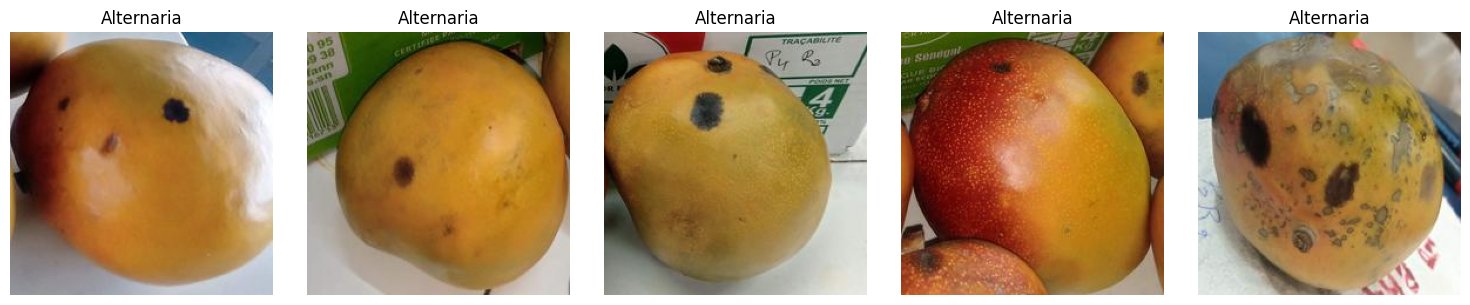

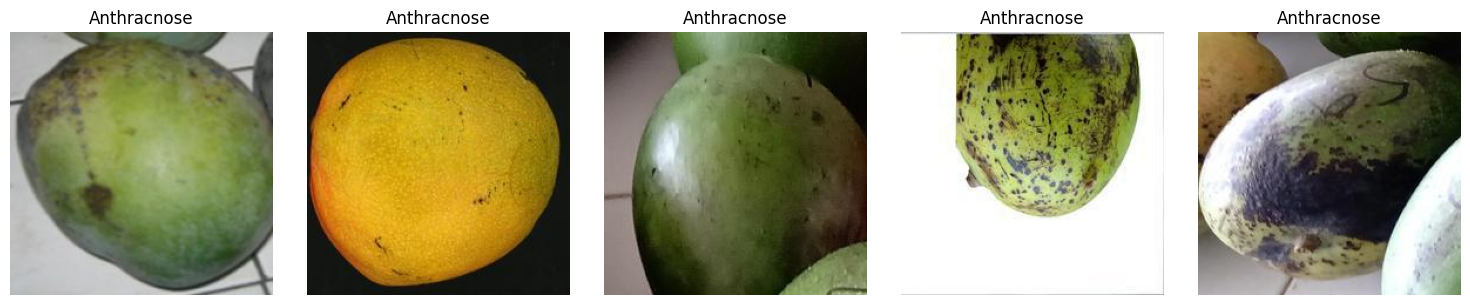

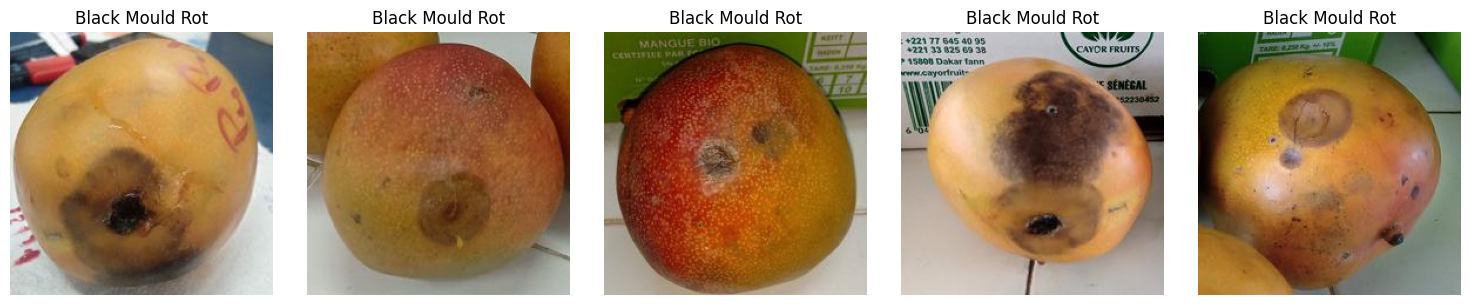

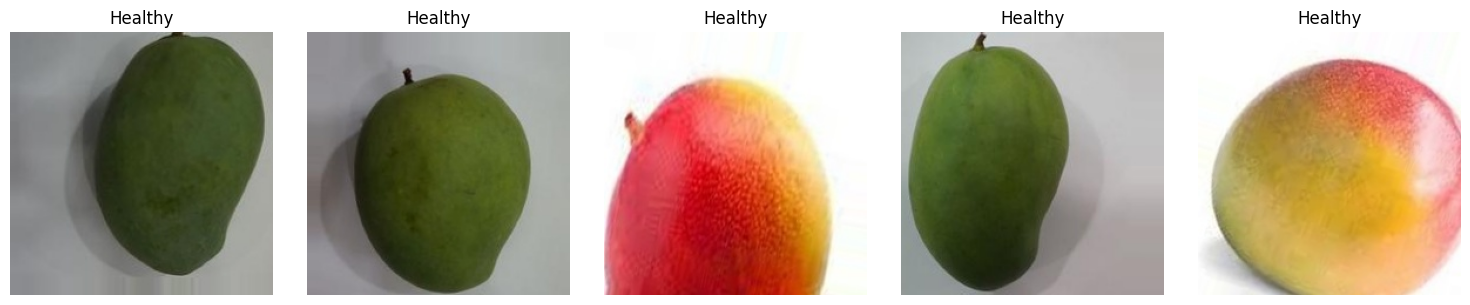

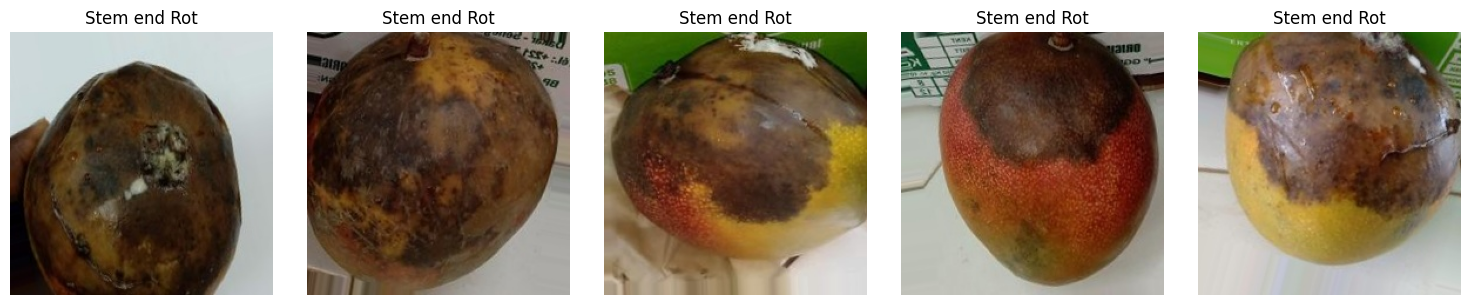

In [9]:
for class_name in class_folders:

    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ]

    # Take up to 5 images
    selected_images = image_files[:5]

    plt.figure(figsize=(15, 3))

    for i, filename in enumerate(selected_images):

        image_path = os.path.join(class_path, filename)

        image = Image.open(image_path)

        plt.subplot(1, len(selected_images), i + 1)

        plt.imshow(image)

        plt.title(class_name)

        plt.axis("off")

    plt.tight_layout()

    plt.show()

In [10]:
image_sizes = []

for class_name in class_folders:

    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ]

    for filename in image_files:

        image_path = os.path.join(class_path, filename)

        try:

            with Image.open(image_path) as image:

                image_sizes.append(image.size)

        except Exception:
            pass

In [11]:
from collections import Counter

size_counts = Counter(image_sizes)

print("Number of different image dimensions:", len(size_counts))

print("\nMost common image sizes:")

for size, count in size_counts.most_common(20):

    print(size, ":", count)

Number of different image dimensions: 51

Most common image sizes:
(224, 224) : 4650
(831, 1153) : 7
(634, 427) : 7
(441, 633) : 7
(896, 743) : 7
(162, 125) : 7
(2445, 2252) : 7
(859, 910) : 7
(729, 614) : 7
(170, 181) : 7
(711, 618) : 7
(806, 537) : 7
(724, 644) : 7
(757, 560) : 7
(2786, 2080) : 7
(492, 441) : 7
(1818, 1577) : 7
(378, 264) : 7
(985, 992) : 7
(797, 675) : 7


In [12]:
widths = [size[0] for size in image_sizes]
heights = [size[1] for size in image_sizes]

print("Width")
print("Minimum:", min(widths))
print("Maximum:", max(widths))
print("Average:", np.mean(widths))

print("\nHeight")
print("Minimum:", min(heights))
print("Maximum:", max(heights))
print("Average:", np.mean(heights))

Width
Minimum: 109
Maximum: 2786
Average: 272.4638

Height
Minimum: 116
Maximum: 2252
Average: 265.4736


In [13]:
bad_images = []

for class_name in class_folders:

    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ]

    for filename in image_files:

        image_path = os.path.join(class_path, filename)

        try:

            with Image.open(image_path) as image:

                image.verify()

        except Exception as e:

            bad_images.append(
                (class_name, filename, str(e))
            )


print("Number of corrupted/unreadable images:", len(bad_images))

if len(bad_images) > 0:

    print("\nProblematic images:")

    for item in bad_images[:20]:

        print(item)

Number of corrupted/unreadable images: 0


In [14]:
all_filenames = []

for class_name in class_folders:

    class_path = os.path.join(dataset_path, class_name)

    for filename in os.listdir(class_path):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        ):

            all_filenames.append(filename)


filename_counts = Counter(all_filenames)

duplicate_names = {
    name: count
    for name, count in filename_counts.items()
    if count > 1
}

print("Duplicate filenames:", len(duplicate_names))

if duplicate_names:

    print(list(duplicate_names.items())[:20])

Duplicate filenames: 0


In [15]:
print("SAMPLE FILENAMES")
print("=" * 50)

for class_name in class_folders:

    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ]

    print("\nCLASS:", class_name)

    for filename in image_files[:20]:

        print(filename)

SAMPLE FILENAMES

CLASS: Alternaria
alternaria_001.jpg
alternaria_002.jpg
alternaria_003.jpg
alternaria_004.jpg
alternaria_005.jpg
alternaria_006.jpg
alternaria_007.jpg
alternaria_008.jpg
alternaria_009.jpg
alternaria_010.jpg
alternaria_011.jpg
alternaria_012.jpg
alternaria_013.jpg
alternaria_014.jpg
alternaria_015.jpg
alternaria_016.jpg
alternaria_017.jpg
alternaria_018.jpg
alternaria_019.jpg
alternaria_020.jpg

CLASS: Anthracnose
anthracnose_001.jpg
anthracnose_002.jpg
anthracnose_003.jpg
anthracnose_004.jpg
anthracnose_005.jpg
anthracnose_006.jpg
anthracnose_007.jpg
anthracnose_008.jpg
anthracnose_009.jpg
anthracnose_010.jpg
anthracnose_011.jpg
anthracnose_012.jpg
anthracnose_013.jpg
anthracnose_014.jpg
anthracnose_015.jpg
anthracnose_016.jpg
anthracnose_017.jpg
anthracnose_018.jpg
anthracnose_019.jpg
anthracnose_020.jpg

CLASS: Black Mould Rot
aspergillus_001.jpg
aspergillus_002.jpg
aspergillus_003.jpg
aspergillus_004.jpg
aspergillus_005.jpg
aspergillus_006.jpg
aspergillus_007.jpg


In [16]:
brightness_data = []

for class_name in class_folders:

    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ]

    # Analyze at most 100 images per class
    for filename in image_files[:100]:

        image_path = os.path.join(class_path, filename)

        try:

            image = Image.open(image_path).convert("RGB")

            image_array = np.array(image)

            brightness = image_array.mean()

            brightness_data.append({
                "Class": class_name,
                "Brightness": brightness
            })

        except:
            pass


brightness_df = pd.DataFrame(brightness_data)

print(brightness_df.groupby("Class")["Brightness"].describe())

                 count        mean        std        min         25%  \
Class                                                                  
Alternaria       100.0  113.960291  21.906208  69.529284   99.297044   
Anthracnose      100.0  100.523871  24.953876  59.070950   81.861571   
Black Mould Rot  100.0  113.464042  17.760801  52.371864  103.035276   
Healthy          100.0  124.363784  35.916333  48.442164   98.098304   
Stem end Rot     100.0   95.797594  15.835671  55.694628   85.250513   

                        50%         75%         max  
Class                                                
Alternaria       113.843697  124.736288  204.853509  
Anthracnose       95.102762  114.445736  191.143827  
Black Mould Rot  113.812291  123.375693  151.787010  
Healthy          126.265655  150.075986  200.502206  
Stem end Rot      95.858774  104.705035  134.064845  


<Figure size 1200x600 with 0 Axes>

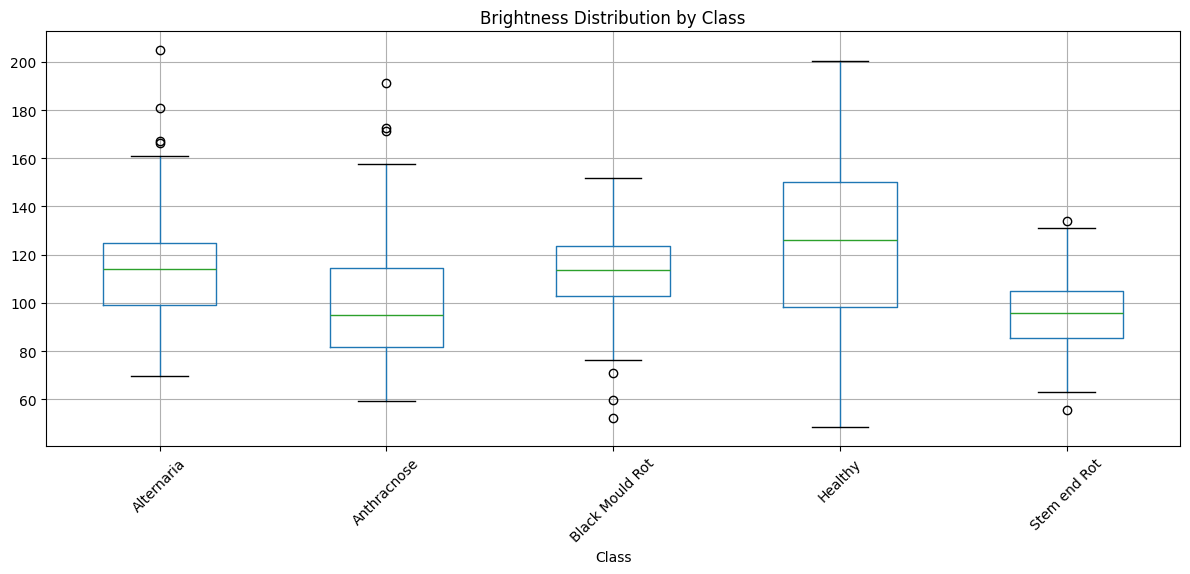

In [17]:
plt.figure(figsize=(12, 6))

brightness_df.boxplot(
    column="Brightness",
    by="Class",
    figsize=(12, 6)
)

plt.title("Brightness Distribution by Class")
plt.suptitle("")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [18]:
print("=" * 60)
print("MANGO FRUIT DISEASE DATASET - EDA SUMMARY")
print("=" * 60)

print("Dataset path:")
print(dataset_path)

print("\nNumber of classes:")
print(len(class_folders))

print("\nClasses:")
for i, class_name in enumerate(class_folders):
    print(i, "-", class_name)

print("\nTotal images:")
print(total_images)

print("\nClass distribution:")

for class_name, count in class_counts.items():

    percentage = count / total_images * 100

    print(
        f"{class_name:30s} : "
        f"{count:5d} images "
        f"({percentage:.2f}%)"
    )

print("\nImage dimensions:")
print("Different dimensions:", len(size_counts))

print("\nCorrupted images:")
print(len(bad_images))

print("\nAverage width:")
print(round(np.mean(widths), 2))

print("Average height:")
print(round(np.mean(heights), 2))

print("\nSmallest class:")
print(min_class, "-", class_counts[min_class])

print("Largest class:")
print(max_class, "-", class_counts[max_class])

print("\nImbalance ratio:")
print(round(ratio, 2))

print("=" * 60)

MANGO FRUIT DISEASE DATASET - EDA SUMMARY
Dataset path:
D:\Fruit Disease detection\Mango Fruit Dataset

Number of classes:
5

Classes:
0 - Alternaria
1 - Anthracnose
2 - Black Mould Rot
3 - Healthy
4 - Stem end Rot

Total images:
5000

Class distribution:
Alternaria                     :  1000 images (20.00%)
Anthracnose                    :  1000 images (20.00%)
Black Mould Rot                :  1000 images (20.00%)
Healthy                        :  1000 images (20.00%)
Stem end Rot                   :  1000 images (20.00%)

Image dimensions:
Different dimensions: 51

Corrupted images:
0

Average width:
272.46
Average height:
265.47

Smallest class:
Alternaria - 1000
Largest class:
Alternaria - 1000

Imbalance ratio:
1.0
